In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from collections import defaultdict
import glob 
import os
print(os.getcwd())

/home/savvyfox/Projects/scg-exp/examples/rl


In [2]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w) / w, mode='valid')
    
def load_from_log_file(path):
    '''Return x, y sequence data from the stat csv.'''
    with open(path, 'r') as f:
        lines = f.readlines()
    # Labels.
    xk, yk = [k.strip() for k in lines[0].strip().split(',')]
    # Values.
    x, y = [], []
    for line in lines[1:]:
        data = line.strip().split(',')
        x.append(float(data[0].strip()))
        y.append(float(data[1].strip()))
    x = np.array(x)
    y = np.array(y)
    return xk, x, yk, y

#### For reporting
def log(msg):
    log_messages.append(msg)
    print(msg)

In [3]:
plot_colors = {
    'GP-MPC': 'royalblue',
    'PPO': 'darkorange',
    'SAC': 'red',
    'DPPO': 'pink',
    'PPO-MPC': 'tan',
    'iLQR': 'darkgray',
    'Linear MPC': 'green',
    'Nonlinear MPC': 'cadetblue',
    "iLQR": "tab:gray",
    'MAX': 'none',
    'MIN': 'none',
}

legends = {
    "ref": "black",
    "PPO": "PPO",
    "PPO3": "PPO with ilqr ref",
    "PPO4": "PPO with ilqr state ref",
    "SAC": "SAC",
    "TD3": "TD3",
    "DPPO": "DPPO",
    "GP-MPC": "GP-MPC",
    "PPO-MPC": "PPO-MPC"
}

In [27]:
#### Data info
# data_dir = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/prefinal"
# data_dir = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/prefinal_ilqr_ref"
data_dir1 = "/home/savvyfox/Misc/Olaf/Projects/scg-exp/examples/rlmpc/Results/ppo_mpc_update"
data_dir0 = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/final_7"
data_dir2 = "/home/savvyfox/Misc/lsy_workstation_06/Projects/scg-exp/examples/rl/Results/final3"
data_dir4 = "/home/savvyfox/Misc/lsy_workstation_06/Projects/scg-exp/examples/rl/Results/Final_July"
data_dir5 = "/home/savvyfox/Misc/lsy_workstation_02/Projects/scg-exp/examples/rl/Results/fina_test"
data_dir6 = "/home/savvyfox/Projects/Data/Benchmark_August2"
exp_name = "generalization"
data_paths = {
    "PPO": data_dir6 + "/" + exp_name + "/quadrotor_2D_attitude_ppo_data",
    "SAC": data_dir6 + "/" + exp_name + "/quadrotor_2D_attitude_sac_data",
    "DPPO": data_dir6 + "/" + exp_name + "/quadrotor_2D_attitude_dppo_data",
    # "PPO-MPC": data_dir6 + "/" + exp_name + "/quadrotor_2D_attitude_ppo_mpc_data",
}

#### Seeds
n_seeds = 10
seeds = [i for i in range(0, n_seeds)] 
log_messages = []

## Performance metric

In [28]:
perf_metric = defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []})
log("Task Performance")
for method in data_paths.keys():
    for seed in seeds:
        path = data_paths[method] + "/seed"+ str(seed) +"_*/perf_metric.npy"
        file_path = glob.glob(path)
        temp = np.load(file_path[0], allow_pickle=True).item()
        perf_metric[method]['rmse'].append(temp['rmse'])
        perf_metric[method]['rmse_std'].append(temp['rmse_std'])
    log(f"Performance of {method} is {np.array(perf_metric[method]['rmse']).mean()} +/- {np.array(perf_metric[method]['rmse']).std()}") 

Task Performance
Performance of PPO is 0.04332131159015875 +/- 0.011668152944673297
Performance of SAC is 0.017822659834278647 +/- 0.003671639546900827
Performance of DPPO is 0.04969637060414502 +/- 0.020515440300596655


In [29]:
log("\n")

### Convergence plot

In [30]:
perf_data = defaultdict(lambda: defaultdict())
for method in data_paths.keys():
    print(method)
    temp = [x for x in os.listdir(data_paths[method])]
    for sd in os.listdir(data_paths[method]):
        seed = sd[4]
        xk, x, lk, l = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_length.log")
        xk, x, yk, y = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_return.log")
        xk, x, zk, z = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/ep_return_std.log")
        # xk, x, ck, c = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/constraint_violation.log")
        xk, x, yk, m = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/rmse.log")
        xk, x, yk, n = load_from_log_file(data_paths[method] +"/"+sd+ "/logs/stat_eval/rmse_std.log")
        perf_data[method].update({int(seed): {"data": x, "ep_return": y, "ep_return_std": z, "rmse": m, "rmse_std": n, "ep_length": l}})

PPO
SAC
DPPO


In [31]:
# gp_name = '/gpmpc_acados_TP_hpo_convergence_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# gp_mpc_data['rmse'][:, -1].mean()

Sample efficiency
PPO
For PPO, Threshold: 0.07209671693229597 with data axis: 805200.0
SAC
For SAC, Threshold: 0.02033301704145615 with data axis: 435600.0
DPPO
For DPPO, Threshold: 0.12164995708187692 with data axis: 620400.0




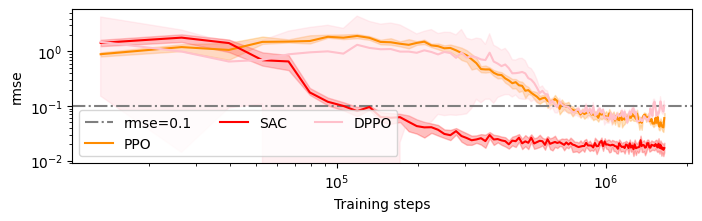

In [32]:
eval_data = {}
log("Sample efficiency")
mean_fn = np.percentile
perc = 80
threshold, samples_till = 1.2, 2.0e6

fig = plt.figure(figsize=(8, 2)) 
plt.axhline(xmin=0.0, xmax=1.95, y=0.1, linestyle='-.', color=plot_colors["iLQR"], label='rmse=0.1')

# plt.plot(gp_mpc_data['train_steps'], mean_fn(gp_mpc_data['rmse'], perc, axis=0), color=plot_colors["GP-MPC"], label='GP-MPC')
# plt.fill_between(gp_mpc_data['train_steps'], 
#                 np.clip(mean_fn(gp_mpc_data['rmse'], perc, axis=0)-gp_mpc_data['rmse'].std(axis=0), 0, 10), 
#                 np.clip(mean_fn(gp_mpc_data['rmse'], perc, axis=0)+gp_mpc_data['rmse'].std(axis=0), 0, 10), 
#                 color=plot_colors["GP-MPC"], alpha=0.25)

for t, method in enumerate(data_paths.keys()):
    print(method)
    temp = np.zeros((n_seeds, 6, perf_data[method][seeds[0]]["data"].shape[0]))
    for seed in seeds:
        temp[seed, 0, :] = perf_data[method][seed]["data"]
        temp[seed, 1, :] = perf_data[method][seed]["ep_return"]
        temp[seed, 2, :] = perf_data[method][seed]["ep_return_std"]
        temp[seed, 3, :] = perf_data[method][seed]["rmse"]
        temp[seed, 4, :] = perf_data[method][seed]["rmse_std"]
        temp[seed, 5, :] = perf_data[method][seed]["ep_length"]
    eval_data.update({method: temp})
    rmse_mean = mean_fn(temp[:,3,:], perc, axis=0)
    rmse_ref = rmse_mean[-1]
    # if perf_metric:
    #     rmse_ref = np.array(perf_metric[method]['rmse']).mean()
    mask = rmse_mean < threshold * rmse_ref
    log(f"For {method}, Threshold: {threshold * rmse_ref} with data axis: {temp[0,0, mask][0]}")

    plt.plot(temp[0,0,:]+1, rmse_mean, color=plot_colors[method], label=legends[method])
    plt.fill_between(temp[0,0,:]+1, 
                     np.clip(mean_fn(temp[:,3,:]-temp[:,4,:], perc, axis=0), 0, 10),  
                     np.clip(mean_fn(temp[:,3,:]+temp[:,4,:], perc, axis=0), 0, 10), color=plot_colors[method], alpha=0.25)

plt.legend(ncol=3)
# plt.xlim(1, 800000)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training steps")
plt.ylabel("rmse")
# plt.title("Task: Quadrotor 2D")
# plt.savefig("performance_logx.pdf",bbox_inches="tight", pad_inches=0.1)
log("\n")

## Generalization metric

In [33]:
transfer_metric = defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []})
for method in data_paths.keys():
    for seed in seeds:
        path = data_paths[method] + "/seed"+ str(seed) +"_*/transfer_metric_11.npy"
        file_path = glob.glob(path)
        temp = np.load(file_path[0], allow_pickle=True).item()
        transfer_metric[method]['rmse'].append(temp['rmse'])
        transfer_metric[method]['rmse_std'].append(temp['rmse_std'])
    print(f"Performance of {method} is {np.array(perf_metric[method]['rmse']).mean()} +/- {np.array(perf_metric[method]['rmse']).std()}")

Performance of PPO is 0.04332131159015875 +/- 0.011668152944673297
Performance of SAC is 0.017822659834278647 +/- 0.003671639546900827
Performance of DPPO is 0.04969637060414502 +/- 0.020515440300596655


In [34]:
episode_len_list = [9, 10, 11, 12, 13, 14, 15]
episode_len_list2 = [4.5, 5, 5.5, 6, 6.5, 7, 7.5]
log("Generalization metric")
transfer_metric = defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []})
for method in data_paths.keys():
    transfer_metric.update({method: {'rmse': [], 'rmse_std': []}})
    for T in episode_len_list:
        rmse, rmse_std = [], []
        for seed in seeds:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/transfer_metric_"+str(T)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            rmse.append(temp['rmse'])
            rmse_std.append(temp['rmse_std'])
        transfer_metric[method]['rmse'].append(np.array(rmse).mean())
        transfer_metric[method]['rmse_std'].append(np.array(rmse_std).mean())
        log(f"Performance of {method} for episode length of {T} is {np.array(rmse).mean()} +/- {np.array(rmse_std).mean()}")
    transfer_metric[method]['rmse'] = np.array(transfer_metric[method]['rmse'])
    transfer_metric[method]['rmse_std'] = np.array(transfer_metric[method]['rmse_std'])
    log("")
log("\n")

Generalization metric
Performance of PPO for episode length of 9 is 0.05565260437645534 +/- 0.001567284266858655
Performance of PPO for episode length of 10 is 0.047763838447157786 +/- 0.0015746075750709796
Performance of PPO for episode length of 11 is 0.04361093040951127 +/- 0.001368089981061116
Performance of PPO for episode length of 12 is 0.04540152738773088 +/- 0.0012839367021444566
Performance of PPO for episode length of 13 is 0.0435516545179884 +/- 0.001376831244905986
Performance of PPO for episode length of 14 is 0.04294370967055063 +/- 0.0013220450199395836
Performance of PPO for episode length of 15 is 0.04242318204320436 +/- 0.0011342891767490136

Performance of SAC for episode length of 9 is 0.02401892444350858 +/- 0.0010191755376863538
Performance of SAC for episode length of 10 is 0.023608169761776984 +/- 0.001237050032333882
Performance of SAC for episode length of 11 is 0.017830757926057907 +/- 0.0006390136468395815
Performance of SAC for episode length of 12 is 0.01

In [35]:
# gp_name = exp_name + '/gpmpc_acados_TP_tr_gen_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data)
# dummy_list = ['_9', '_10', '_11', '_12', '_13', '_14', '_15']
# gpmpc_gen = {'rmse': [], 'rmse_std': []}
# for i in dummy_list:
#     gpmpc_gen['rmse'].append(gp_mpc_data[i]['mean_rmse'])
#     gpmpc_gen['rmse_std'].append(gp_mpc_data[i]['std_rmse'])

Text(0, 0.5, 'rmse')

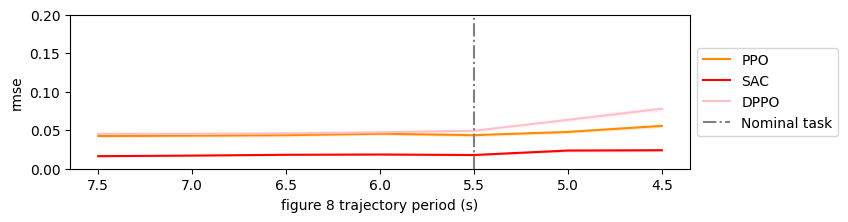

In [36]:
fig = plt.figure(figsize=(8, 2))
for method in data_paths.keys():
    plt.plot(episode_len_list2, transfer_metric[method]['rmse'], label=method, color=plot_colors[method])
    plt.fill_between(episode_len_list2, 
                     transfer_metric[method]['rmse']-transfer_metric[method]['rmse_std'],  
                     transfer_metric[method]['rmse']+transfer_metric[method]['rmse_std'], color=plot_colors[method], alpha=0.1)

#### GP-MPC
# plt.plot(episode_len_list2, gpmpc_gen['rmse'], label='GP-MPC', color=plot_colors['GP-MPC'])
# plt.fill_between(episode_len_list2, 
#                  np.array(gpmpc_gen['rmse'])-np.array(gpmpc_gen['rmse_std']),  
#                  np.array(gpmpc_gen['rmse'])+np.array(gpmpc_gen['rmse_std']), color=plot_colors['GP-MPC'], alpha=0.1)

plt.axvline(x=5.5, linestyle='-.', color=plot_colors['iLQR'], label= 'Nominal task')
# plt.axvline(x=7.5, linestyle='-.', color=plot_colors['iLQR'])
# plt.axvline(x=4.5, linestyle='-.', color=plot_colors['iLQR'])

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(0,0.2)
plt.gca().invert_xaxis()
plt.xlabel("figure 8 trajectory period (s)")
plt.ylabel("rmse")
# plt.savefig("generalization_curve.pdf",bbox_inches="tight", pad_inches=0.1)

In [116]:
np.save('generalization_results_generalization.npy', dict(transfer_metric))

In [117]:
dict(transfer_metric)

{'PPO': {'rmse': array([0.05472789, 0.04797281, 0.04482432, 0.04518381, 0.04585157,
         0.04660329, 0.04711454]),
  'rmse_std': array([0.00219937, 0.00114555, 0.00118694, 0.00113131, 0.00124754,
         0.00129742, 0.00154312])},
 'SAC': {'rmse': array([0.02443952, 0.02291567, 0.01742131, 0.01737355, 0.01643455,
         0.01489769, 0.01417034]),
  'rmse_std': array([0.00082773, 0.00113244, 0.00049242, 0.00038704, 0.00033867,
         0.00029543, 0.00026479])},
 'DPPO': {'rmse': array([0.0527608 , 0.04130301, 0.03853528, 0.03873645, 0.03880628,
         0.03733203, 0.03721215]),
  'rmse_std': array([0.00294574, 0.00134558, 0.0014729 , 0.0014311 , 0.00140525,
         0.00109333, 0.00130302])}}

## Robustness metric

### Observation noise

In [37]:
metric = defaultdict(lambda: defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []}))
noise_scale = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
noise_scale = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100,
              110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
for method in data_paths.keys():
    print(method)
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_ob_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            metric[method][ns]['rmse'].append(temp['rmse'])
            metric[method][ns]['rmse_std'].append(temp['rmse_std'])

PPO
SAC
DPPO


Robustness metric: Observation noise (relative)
Robustness for PPO is 35
Robustness for SAC is 60
Robustness for DPPO is 30


Text(0, 0.5, 'Relative Performance %')

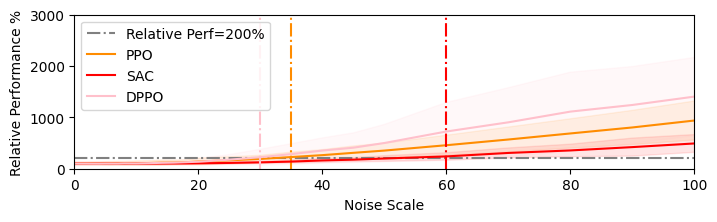

In [38]:
threshold = 200
log("Robustness metric: Observation noise (relative)")
fig = plt.figure(figsize=(8, 2))
plt.plot(noise_scale, [threshold]*len(noise_scale), color='grey', linestyle='-.', label='Relative Perf='+str(threshold)+'%')
for method in metric.keys():
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till, perf0 = 200, None
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        if perf0 is None:
            perf0 = data.mean()
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        # if not all(metric[method][ns]['success']) and traj_success_till > ns:
        #     traj_success_till = ns
        if data.mean()*100/perf0 > threshold and traj_success_till > ns:
            traj_success_till = ns
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    log(f"Robustness for {method} is {traj_success_till}")
    
    plt.plot(noise_scale, temp*100/temp[0], color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, temp_std1*100/temp[0], temp_std2*100/temp[0], color=plot_colors[method], alpha=0.1)
    plt.axvline(x=traj_success_till, linestyle='-.', color=plot_colors[method])
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.legend()
plt.ylim(0,3000)
plt.xlim(0,100)
plt.xlabel("Noise Scale")
plt.ylabel("Relative Performance %")
# plt.savefig("robustness_ob_rl.pdf",bbox_inches="tight", pad_inches=0.1)

Robustness metric: Observation noise (absolute)
Robustness for PPO is 70
Robustness for SAC is 170
Robustness for DPPO is 45


Text(0, 0.5, 'rmse')

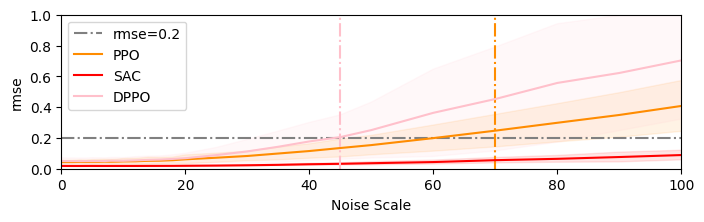

In [39]:
threshold = 0.2
log("Robustness metric: Observation noise (absolute)")
fig = plt.figure(figsize=(8, 2))
plt.plot(noise_scale, [threshold]*len(noise_scale), color='grey', linestyle='-.', label='rmse='+str(threshold))
for method in metric.keys():
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 200
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        if data.mean() > threshold and traj_success_till > ns:
            traj_success_till = ns
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    log(f"Robustness for {method} is {traj_success_till}")
    
    plt.plot(noise_scale, temp, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, temp_std1, temp_std2, color=plot_colors[method], alpha=0.1)
    plt.axvline(x=traj_success_till, linestyle='-.', color=plot_colors[method])
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.legend()
plt.ylim(0,1.0)
plt.xlim(0,100)
plt.xlabel("Noise Scale")
plt.ylabel("rmse")
# plt.savefig("robustness_ob_rl.pdf",bbox_inches="tight", pad_inches=0.1)

In [40]:
log("\n")

### Process Noise

In [41]:
metric = defaultdict(lambda: defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []}))
noise_scale = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40, 50]
noise_scale = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
for method in data_paths.keys():
    print(method)
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_ps_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            metric[method][ns]['rmse'].append(temp['rmse'])
            metric[method][ns]['rmse_std'].append(temp['rmse_std'])

PPO
SAC
DPPO


In [42]:
# gp_name =  'ps5/gpmpc_acados_TP_proc_ns=5_proc_noise_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data['rmse_mean'][:13])
# print(gp_mpc_data.keys())

Robustness metric: Process noise (relative)
Robustness for PPO is 12
Robustness for SAC is 5
Robustness for DPPO is 10


Text(0, 0.5, 'Relative Performance %')

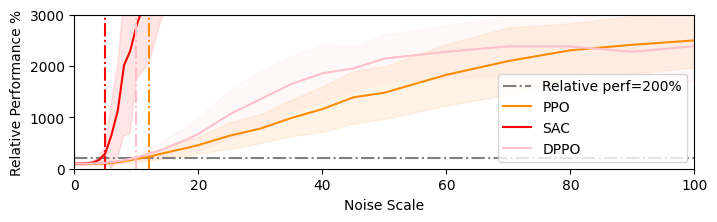

In [43]:
threshold = 200
log("Robustness metric: Process noise (relative)")
fig = plt.figure(figsize=(8, 2))
plt.plot(noise_scale, [threshold]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf='+str(threshold)+'%')
for method in metric.keys():
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till, perf0 = 200, None
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        if perf0 is None:
            perf0 = data.mean()
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        if data.mean()*100/perf0 > threshold and traj_success_till > ns:
            traj_success_till = ns
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    log(f"Robustness for {method} is {traj_success_till}")
    
    plt.plot(noise_scale, temp*100/temp[0], color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, temp_std1*100/temp[0], temp_std2*100/temp[0], color=plot_colors[method], alpha=0.1)
    plt.axvline(x=traj_success_till, linestyle='-.', color=plot_colors[method])
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.legend()
plt.ylim(0,3000)
plt.xlim(0,100)
plt.xlabel("Noise Scale")
plt.ylabel("Relative Performance %")
# plt.savefig("robustness_ps_rl.pdf",bbox_inches="tight", pad_inches=0.1)

Robustness metric: Process noise (absolute)
Robustness for PPO is 14
Robustness for SAC is 7
Robustness for DPPO is 12
Robustness for PPO-MPC is 9


Text(0, 0.5, 'rmse')

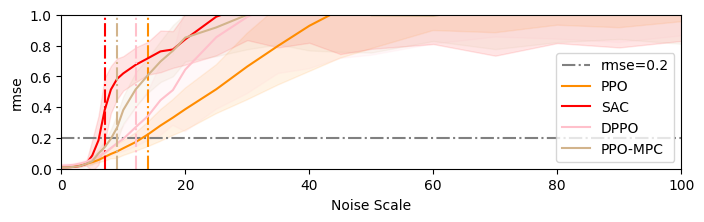

In [21]:
threshold = 0.2
log("Robustness metric: Process noise (absolute)")
fig = plt.figure(figsize=(8, 2))
plt.plot(noise_scale, [threshold]*len(noise_scale), color='grey', linestyle='-.', label='rmse='+str(threshold))
for method in metric.keys():
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 200
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
        if data.mean() > threshold and traj_success_till > ns:
            traj_success_till = ns
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    log(f"Robustness for {method} is {traj_success_till}")
    
    plt.plot(noise_scale, temp, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, temp_std1, temp_std2, color=plot_colors[method], alpha=0.1)
    plt.axvline(x=traj_success_till, linestyle='-.', color=plot_colors[method])
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.legend()
plt.ylim(0,1.0)
plt.xlim(0,100)
plt.xlabel("Noise Scale")
plt.ylabel("rmse")
# plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_ps_rl.pdf",bbox_inches="tight", pad_inches=0.1)

In [145]:
log("\n")

### Parametric noise

In [44]:
metric = defaultdict(lambda: defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []}))
# noise_scale = [0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 4.5, 5.0]
noise_scale = [0, 0.05, 0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0]
for method in data_paths.keys():
    print(method)
    for seed in seeds:
        for ns in noise_scale:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_pm_"+str(ns)+".npy"
            # print(path)
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            metric[method][ns]['rmse'].append(temp['rmse'])
            metric[method][ns]['rmse_std'].append(temp['rmse_std'])

PPO
SAC
DPPO


Robustness metric: Parametric noise (relative)
Robustness for PPO is 3.5
Robustness for SAC is 2.0
Robustness for DPPO is 2.5


Text(0, 0.5, 'Relative Performance %')

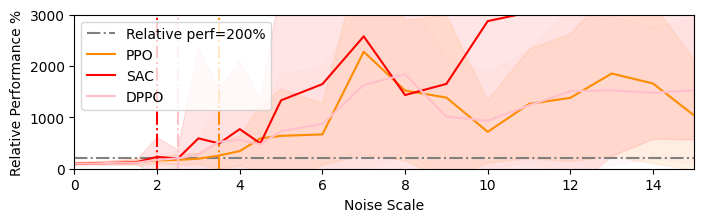

In [47]:
threshold = 200
log("Robustness metric: Parametric noise (relative)")
fig = plt.figure(figsize=(8, 2))
plt.plot(noise_scale, [threshold]*len(noise_scale), color='grey', linestyle='-.', label='Relative perf='+str(threshold)+'%')
for method in metric.keys():
    temp, tempstd, temp_std1, temp_std2 = [], [], [], []
    traj_success_till, perf0 = 200, None
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        tempstd.append(data.std())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        if perf0 is None:
            perf0 = data.mean()
        if data.mean()*100/perf0 > threshold and traj_success_till > ns:
            traj_success_till = ns
            
    temp = np.array(temp)
    tempstd = np.array(tempstd)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    log(f"Robustness for {method} is {traj_success_till}")
    
    plt.plot(noise_scale, temp*100/temp[0], color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, temp_std1*100/temp[0], temp_std2*100/temp[0], color=plot_colors[method], alpha=0.1)
    plt.axvline(x=traj_success_till, linestyle='-.', color=plot_colors[method])
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.legend()
plt.ylim(0,3000)
plt.xlim(0,15)
plt.xlabel("Noise Scale")
plt.ylabel("Relative Performance %")
# plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_pm_rl.pdf",bbox_inches="tight", pad_inches=0.1)

Robustness metric: Parametric noise (absolute)
Robustness for PPO is 4.5
Robustness for SAC is 5.0
Robustness for DPPO is 3.5


Text(0, 0.5, 'rmse')

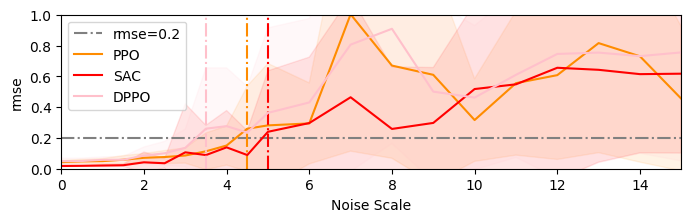

In [48]:
threshold = 0.2
log("Robustness metric: Parametric noise (absolute)")
fig = plt.figure(figsize=(8, 2))
plt.plot(noise_scale, [threshold]*len(noise_scale), color='grey', linestyle='-.', label='rmse='+str(threshold))
for method in metric.keys():
    temp, tempstd, temp_std1, temp_std2 = [], [], [], []
    traj_success_till = 200
    for k, ns in enumerate(noise_scale):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        tempstd.append(data.std())
        temp_std1.append(data.mean() - 1*data.std())
        temp_std2.append(data.mean() + 1*data.std())
        if data.mean() > threshold and traj_success_till > ns:
            traj_success_till = ns
            
    temp = np.array(temp)
    tempstd = np.array(tempstd)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    log(f"Robustness for {method} is {traj_success_till}")
    
    plt.plot(noise_scale, temp, color=plot_colors[method], label=method)
    plt.fill_between(noise_scale, temp_std1, temp_std2, color=plot_colors[method], alpha=0.1)
    plt.axvline(x=traj_success_till, linestyle='-.', color=plot_colors[method])
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.legend()
plt.ylim(0,1.0)
plt.xlim(0,15)
plt.xlabel("Noise Scale")
plt.ylabel("rmse")
# plt.title("TD3 for Quadrotor 2D")
# plt.savefig("robustness_pm_rl.pdf",bbox_inches="tight", pad_inches=0.1)

In [130]:
log("\n")

### Robustness Metric: Downwash

In [62]:
metric = defaultdict(lambda: defaultdict(lambda: {'rmse': [], 'rmse_std': [], 'success': []}))
downwash_height = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 4.5]
for method in data_paths.keys():
    print(method)
    for seed in seeds:
        for ns in downwash_height:
            path = data_paths[method] + "/seed"+ str(seed) +"_*/robust_metric_dw_"+str(ns)+".npy"
            file_path = glob.glob(path)
            temp = np.load(file_path[0], allow_pickle=True).item()
            metric[method][ns]['rmse'].append(temp['rmse'])
            metric[method][ns]['rmse_std'].append(temp['rmse_std'])

PPO


IndexError: list index out of range

In [63]:
# gp_name = 'nominal/gpmpc_acados_TP_downwash_results.npy'
# gp_mpc_data = np.load("./Data/" + gp_name, allow_pickle=True).item()
# print(gp_mpc_data['rmse_mean'][:13])
# print(gp_mpc_data.keys())
# print(gp_mpc_data['dw_height'])

Robustness for PPO is 50
Robustness for SAC is 50
Robustness for DPPO is 50


Text(0, 0.5, 'rmse')

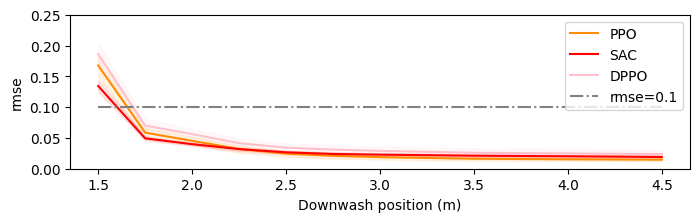

In [41]:
fig = plt.figure(figsize=(8, 2))

for method in metric.keys():
    temp, temp_std1, temp_std2 = [], [], []
    traj_success_till = 50
    for k, ns in enumerate(downwash_height):
        data = np.array(metric[method][ns]['rmse'])
        temp.append(data.mean())
        temp_std1.append(data.mean() - data.std())
        temp_std2.append(data.mean() + data.std())
    temp = np.array(temp)
    temp_std1, temp_std2 = np.array(temp_std1), np.array(temp_std2)
    print(f"Robustness for {method} is {traj_success_till}")

    plt.plot(downwash_height, temp, color=plot_colors[method], label=method)
    plt.fill_between(downwash_height, temp_std1, temp_std2, color=plot_colors[method], alpha=0.1)   
    # plt.fill_between([traj_success_till, 100], [1, 1], color='r', alpha=0.25, label=method)

plt.plot(downwash_height, [0.1]*len(downwash_height), color='grey', linestyle='-.', label='rmse=0.1')

plt.legend()
plt.ylim(0,0.25)
plt.xlabel("Downwash position (m)")
plt.ylabel("rmse")
# plt.savefig("robustness_dw_rl.pdf",bbox_inches="tight", pad_inches=0.1)

## Performance report

In [150]:
print("\n".join(log_messages))

Task Performance
Performance of PPO is 0.04659914830771016 +/- 0.013072522173711945
Performance of SAC is 0.2116916885943103 +/- 0.027602519172124303
Performance of DPPO is 0.07321374334228871 +/- 0.03984563306164843
Sample efficiency
For PPO, Threshold: 0.7457874435956111 with data axis: 26400.0
For SAC, Threshold: 1.0517617427119428 with data axis: 26400.0
For DPPO, Threshold: 1.2755394483347648 with data axis: 13200.0


Robustness metric: Observation noise (relative)
Robustness for PPO is 60
Robustness for SAC is 200
Robustness for DPPO is 80
Robustness metric: Observation noise (absolute)
Robustness for PPO is 100
Robustness for SAC is 0
Robustness for DPPO is 100
Robustness metric: Process noise (relative)
Robustness for PPO is 20
Robustness for SAC is 14
Robustness for DPPO is 25
Robustness metric: Process noise (absolute)
Robustness for PPO is 35
Robustness for SAC is 0
Robustness for DPPO is 30


Robustness metric: Parametric noise (relative)
Robustness for PPO is 200
Robustnes

### Rough plots for individual seeds

In [31]:
# colors = {
#     "ref": "black",
#     "PPO": "orange",
#     "PPO2": "red",
#     "PPO3": "tab:cyan",
#     "PPO4": "royalblue",
#     "DPPO": "darkorange",
#     "DPPO2": "red",
#     "DPPO3": "tab:cyan",
#     "DPPO4": "royalblue",
#     "SAC": "royalblue",
#     "iLQR": "tab:gray",
# }
# legends = {
#     "PPO": "PPO",
#     "PPO2": "2",
#     "PPO3": "3",
#     "PPO4": "4",
#     "DPPO": "DPPO",
#     "DPPO2": "2",
#     "DPPO3": "3",
#     "DPPO4": "4",
#     "SAC": "SAC"
# }
# seeds = [i for i in range(0,5)]

In [32]:
# data_paths = {
#     "PPO": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data/",
#     #"PPO2": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data2/",
#     #"PPO3": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data3/",
#     #"PPO4": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_ppo_data4/",
#     #"DPPO": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data/",
#     #"DPPO2": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data2/",
#     #"DPPO3": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data3/",
#     #"DPPO4": "/home/savvyfox/Projects/scg-exp/examples/rl/Results/Benchmark_data/standard_ref/quadrotor_2D_attitude_dppo_data4/",
    
#     #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Test_runs/quadrotor_2D_attitude_ppo_data/',

#     #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_ppo_data/',
#     #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_ppo_data2/',
#     #'DPPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_dppo_data2/',
#     #'SAC': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs/quadrotor_2D_attitude_sac_data2/',
    
#     #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data/',
#     #'PPO2': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data2/',
#     #'PPO3': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data3/',
#     #'PPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_ppo_data2/',
#     #'DPPO': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data/',
#     #'DPPO2': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data2/',
#     #'DPPO3': '/home/savvyfox/Misc/lsy_pc1/Projects/scg-exp/examples/rl/Results/Benchmark_runs_new/quadrotor_2D_attitude_dppo_data3/',
    
# }

# perf_data = {}
# for method in data_paths.keys():
#     print(method)
#     perf_data.update({method: {}})
#     for seed in seeds:
#         # print(data_paths[method] + str(seed) + "/logs/stat_eval/ep_length.log")
#         xk, x, lk, l = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_length.log")
#         xk, x, yk, y = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_return.log")
#         xk, x, zk, z = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/ep_return_std.log")
#         # xk, x, ck, c = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/constraint_violation.log")
#         # perf_data[method].update({seed: {"x": x, "y": y, "c": c}})
#         # perf_data[method].update({seed: {"x": x, "y": y, "z": z, "c": c}})
#         xk, x, yk, m = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/rmse.log")
#         xk, x, yk, n = load_from_log_file(data_paths[method] + str(seed) + "/logs/stat_eval/rmse_std.log")
#         # perf_data[method].update({"x": x, "y": y, "z": z, "x1": x1, "y1": y1, "z1": z1})
#         perf_data[method].update({seed: {"x": x, "y": y, "z": z, "m": m, "n": n, "l": l}})

In [33]:
# eval_data = {}
# w = 1
# fig = plt.figure(figsize=(8, 3))
# mean_fn = np.percentile
# perc = 90
# plot_seeds = True

# for t, method in enumerate(data_paths.keys()):
#     print(method)
#     temp = np.zeros((len(seeds), 6, perf_data[method][seeds[0]]["x"].shape[0]))
#     for seed in seeds:
#         temp[seed, 0, :] = perf_data[method][seed]["x"]
#         temp[seed, 1, :] = perf_data[method][seed]["y"]
#         temp[seed, 2, :] = perf_data[method][seed]["z"]
#         temp[seed, 3, :] = perf_data[method][seed]["m"]
#         temp[seed, 4, :] = perf_data[method][seed]["n"]
#         temp[seed, 5, :] = perf_data[method][seed]["l"]
#     j_max = 0
#     for seed in seeds:
#         for j,k in enumerate(temp[seed, 0, :]):
#             if temp[seed, 5, j] < 660:
#                 temp[seed, 1, j] = np.nan
#                 temp[seed, 2, j] = np.nan
#                 temp[seed, 3, j] = np.nan
#                 temp[seed, 4, j] = np.nan
#     eval_data.update({method: temp})

#     # plot
#     plt.plot(temp[0,0,:], mean_fn(temp[:,3,:], perc, axis=0), color=colors[method], label=legends[method])
#     plt.fill_between(temp[0,0,:], 
#                      np.clip(mean_fn(temp[:,3,:]+w*temp[:,4,:], perc, axis=0), 0, 10),  
#                      np.clip(mean_fn(temp[:,3,:]-w*temp[:,4,:], perc, axis=0), 0, 10), color=colors[method], alpha=0.2)
#     if plot_seeds:
#         for seed in seeds:
#             plt.plot(temp[seed,0,:], temp[seed,3,:], label=seed)
#             plt.fill_between(temp[0,0,:], 
#                              np.clip(temp[seed,3,:]-w*temp[seed,4,:], 0, 10),  
#                              np.clip(temp[seed,3,:]+w*temp[seed,4,:], 0, 10), alpha=0.)



# # s = 1 # time std
# # rmse_ilqr_mean = 0.026000000000000002 * 0
# # rmse_ilqr_std = 0.001843908891458577 * 0
# plt.axhline(xmin=0.0, xmax=1.95, y=0.1, linestyle='-.', color=colors["iLQR"], label='rmse=0.1')
# # plt.fill_between([0.0, last_iter], rmse_ilqr_mean-s*rmse_ilqr_std, rmse_ilqr_mean+s*rmse_ilqr_std, color=colors["iLQR"], alpha=0.25)

# # real experiment data
# # plt.plot(last_iter, 0.086, color=colors['PPO'], marker='x')
# # plt.plot(last_iter, 0.064, color=colors['SAC'], marker='x')

# plt.legend(ncol=3)
# # plt.ylim(-200,00)
# # plt.xlim(right=6e5)
# # plt.xscale("log")
# # plt.yscale("log")
# plt.xlabel("Training steps")
# plt.ylabel("RMSE")
# #plt.title("Task: Quadrotor 2D")
# #plt.savefig("performance_logx.pdf",bbox_inches="tight", pad_inches=0.0)

In [34]:
# mean_fn = np.mean
# for method in eval_data.keys():
#     print(method)
#     print(mean_fn(eval_data[method][:, 3, :], axis=0))